In [9]:
from collections import OrderedDict
from typing import Tuple, Union

import numpy as np
import torch
import torch.nn.functional as F
from torch import nn

## 图像编码器：基于resnet网络结构

### 原resnet的网络结构
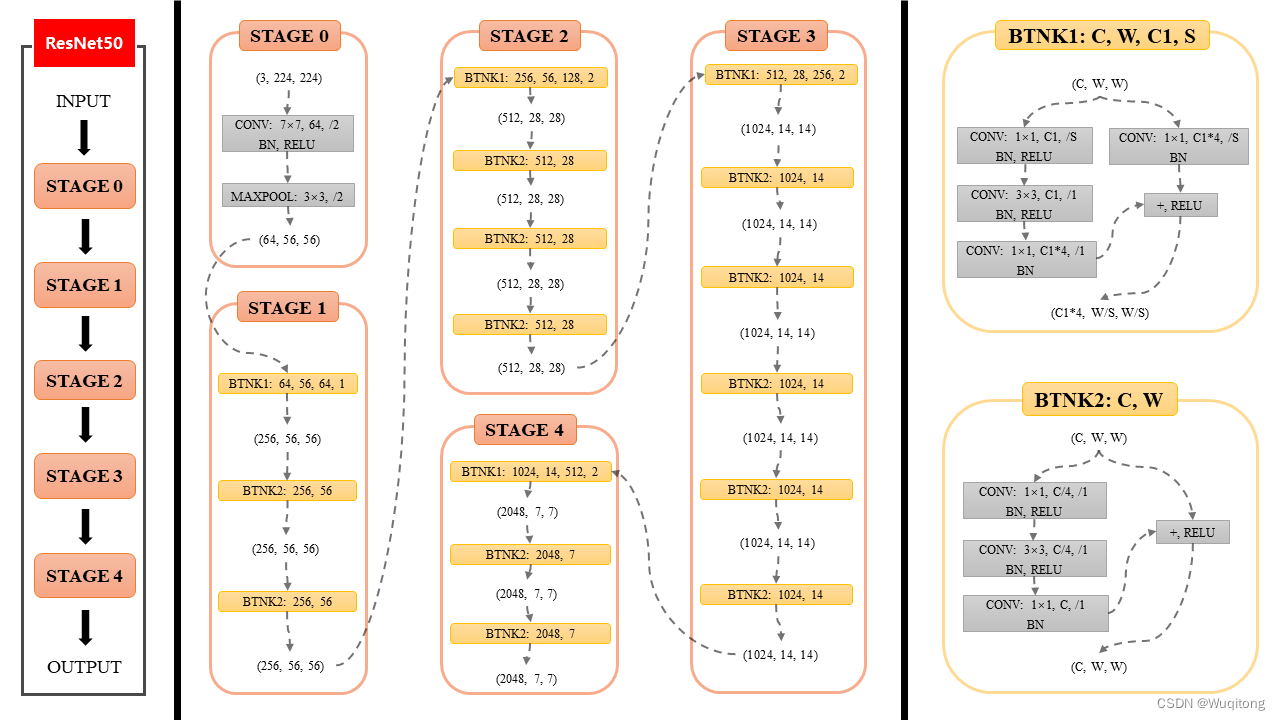

### 下面是clip中修改过的网络结构
一个类似于 torchvision 的 ResNet 类，但包含以下更改：
- 现在有 3 个“stem”卷积，而不是 1 个，并且使用平均池化替代了最大池化。
- 执行反混叠步幅卷积，在步幅 > 1 的卷积前添加了一个平均池化操作。
- 最后的池化层是一个 QKV 注意力机制，而不是平均池化。

In [10]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1):
        super().__init__()

        # all conv layers have stride 1. an avgpool is performed after the second convolution when stride > 1
        self.conv1 = nn.Conv2d(inplanes, planes, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(planes, planes, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu2 = nn.ReLU(inplace=True)

        self.avgpool = nn.AvgPool2d(stride) if stride > 1 else nn.Identity()

        self.conv3 = nn.Conv2d(planes, planes * self.expansion, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu3 = nn.ReLU(inplace=True)

        self.downsample = None
        self.stride = stride

        if stride > 1 or inplanes != planes * Bottleneck.expansion:
            # downsampling layer is prepended with an avgpool, and the subsequent convolution has stride 1
            self.downsample = nn.Sequential(OrderedDict([
                ("-1", nn.AvgPool2d(stride)),
                ("0", nn.Conv2d(inplanes, planes * self.expansion, 1, stride=1, bias=False)),
                ("1", nn.BatchNorm2d(planes * self.expansion))
            ]))

    def forward(self, x: torch.Tensor):
        identity = x

        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.relu2(self.bn2(self.conv2(out)))
        out = self.avgpool(out)
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu3(out)
        return out

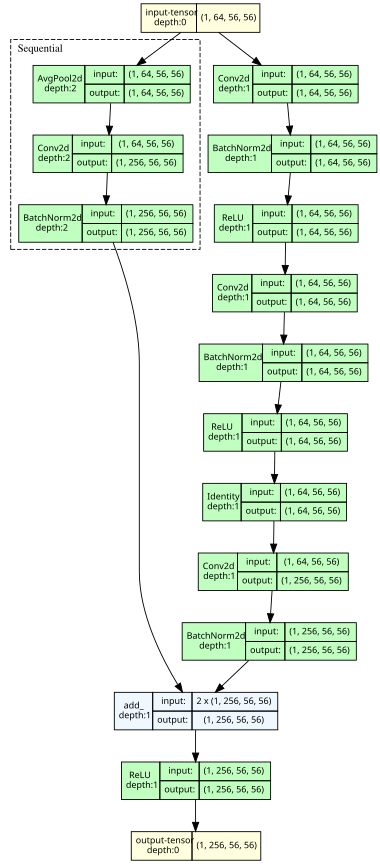

In [11]:
# https://github.com/mert-kurttutan/torchview
from torchview import draw_graph

# 创建Bottleneck模型的一个实例
inplanes = 64  # 示例值
planes = 64    # 示例值
stride = 1     # 示例值
model = Bottleneck(inplanes, planes, stride)

# 创建一个示例输入张量
# 示例输入张量的形状为(批次大小, 输入特征维度, 高度, 宽度)
# 对于Bottleneck，输入特征维度应与inplanes变量相匹配
x = torch.randn(1, inplanes, 56, 56)  # 假设输入尺寸

# 使用torchvis绘制模型
graph = draw_graph(model, input_size=x.shape, expand_nested=True)
graph.visual_graph

In [16]:
class AttentionPool2d(nn.Module):
    def __init__(self, spacial_dim: int, embed_dim: int, num_heads: int, output_dim: int = None):
        super().__init__()
        # 可学习的位置编码的形状取决于序列长度（文本任务为 max_seq_len，图像任务为 H × W）
        # 可学习的位置编码：灵活性更强，训练过程中可以自动适应任务需求， 但是对长度变化敏感，泛化能力可能较弱
        # torch.randn随机初始化可学习位置编码，初始值服从标准正态分布，标准差为：std=1/embed_dim**0.5
        self.positional_embedding = nn.Parameter(torch.randn(spacial_dim ** 2 + 1, embed_dim) / embed_dim ** 0.5)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.c_proj = nn.Linear(embed_dim, output_dim or embed_dim)
        self.num_heads = num_heads

    def forward(self, x):
        x = x.flatten(start_dim=2).permute(2, 0, 1)  # NCHW -> (HW)NC
        print("flat: ",x.shape)
        x = torch.cat([x.mean(dim=0, keepdim=True), x], dim=0)  # (HW+1)NC
        print("cat: ",x.shape)
        x = x + self.positional_embedding[:, None, :].to(x.dtype)  # (HW+1)NC
        print("pos: ",x.shape)
        x, _ = F.multi_head_attention_forward(
            query=x[:1], key=x, value=x,
            embed_dim_to_check=x.shape[-1],
            num_heads=self.num_heads,
            q_proj_weight=self.q_proj.weight,
            k_proj_weight=self.k_proj.weight,
            v_proj_weight=self.v_proj.weight,
            in_proj_weight=None,
            in_proj_bias=torch.cat([self.q_proj.bias, self.k_proj.bias, self.v_proj.bias]),
            bias_k=None,
            bias_v=None,
            add_zero_attn=False,
            dropout_p=0,
            out_proj_weight=self.c_proj.weight,
            out_proj_bias=self.c_proj.bias,
            use_separate_proj_weight=True,
            training=self.training,
            need_weights=False
        )
        print("multihead: ",x.shape)
        return x.squeeze(0)

flat:  torch.Size([256, 2, 256])
cat:  torch.Size([257, 2, 256])
pos:  torch.Size([257, 2, 256])
multihead:  torch.Size([1, 2, 64])


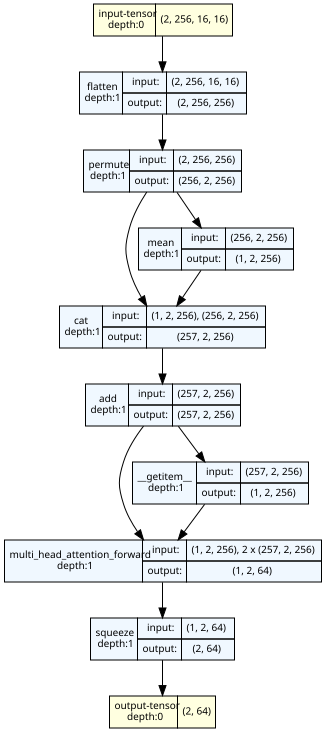

In [21]:
from torchview import draw_graph

# 示例输入张量的形状为(批次大小, 输入特征维度, 高度, 宽度)
N, C, H, W = 2, 256, 16, 16
x = torch.rand(N, C, H, W)

model = AttentionPool2d(spacial_dim=H, embed_dim=C, num_heads=8, output_dim=64)

# 使用torchvis绘制模型
graph = draw_graph(model, input_size=x.shape, expand_nested=True)
graph.visual_graph

flat:  torch.Size([49, 2, 2048])
cat:  torch.Size([50, 2, 2048])
pos:  torch.Size([50, 2, 2048])
multihead:  torch.Size([1, 2, 768])


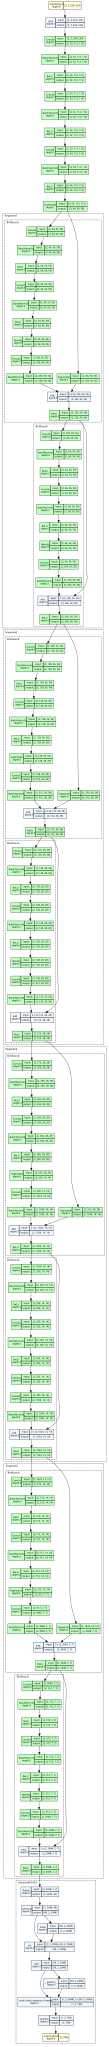

In [27]:
class ModifiedResNet(nn.Module):
    """
    A ResNet class that is similar to torchvision's but contains the following changes:
    - There are now 3 "stem" convolutions as opposed to 1, with an average pool instead of a max pool.
    - Performs anti-aliasing strided convolutions, where an avgpool is prepended to convolutions with stride > 1
    - The final pooling layer is a QKV attention instead of an average pool
    """

    def __init__(self, layers, output_dim, heads, input_resolution=224, width=64):
        super().__init__()
        self.output_dim = output_dim
        self.input_resolution = input_resolution

        # the 3-layer stem
        self.conv1 = nn.Conv2d(3, width // 2, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(width // 2)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(width // 2, width // 2, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(width // 2)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(width // 2, width, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(width)
        self.relu3 = nn.ReLU(inplace=True)
        self.avgpool = nn.AvgPool2d(2)

        # residual layers
        self._inplanes = width  # this is a *mutable* variable used during construction
        self.layer1 = self._make_layer(width, layers[0])
        self.layer2 = self._make_layer(width * 2, layers[1], stride=2)
        self.layer3 = self._make_layer(width * 4, layers[2], stride=2)
        self.layer4 = self._make_layer(width * 8, layers[3], stride=2)

        embed_dim = width * 32  # the ResNet feature dimension
        self.attnpool = AttentionPool2d(input_resolution // 32, embed_dim, heads, output_dim)

    def _make_layer(self, planes, blocks, stride=1):
        layers = [Bottleneck(self._inplanes, planes, stride)]

        self._inplanes = planes * Bottleneck.expansion
        for _ in range(1, blocks):
            layers.append(Bottleneck(self._inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        def stem(x):
            x = self.relu1(self.bn1(self.conv1(x)))
            x = self.relu2(self.bn2(self.conv2(x)))
            x = self.relu3(self.bn3(self.conv3(x)))
            x = self.avgpool(x)
            return x

        x = x.type(self.conv1.weight.dtype)
        x = stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.attnpool(x)

        return x

from torchview import draw_graph

# 示例输入张量的形状为(批次大小, 输入特征维度, 高度, 宽度)
N, C, H, W = 2, 3, 224, 224
x = torch.rand(N, C, H, W)

layers = [2,2,2,2]
output_dim = 768
heads = 8

model = ModifiedResNet(layers,output_dim,heads)

# 使用torchvis绘制模型
graph = draw_graph(model, input_size=x.shape, expand_nested=True)
graph.visual_graph

## 基于ViT的图像编码器
### vit划分patch原理
vit论文做法为将给定的一堆图片按照给定的大小分成一堆Patches。本文将输入的图片尺寸为(224×224)按照16×16大小的Patch进行划分。其中（224×224）/（16×16）=196，因此我们会得到196个patches。到这里我们可以知道每一个Patches数据的shape为[16, 16, 3]。为了满足Transformer的需求，在这里，对每个Patch进行投影变化，映射到一维向量中。即完成如下转化。[16, 16, 3]->[768]，那么这样一来，就将原始的[224, 224, 3]转化为[196, 768]。

### cls token原理
在输入Transformer Encoder之前，值得注意的是需要加上[class] token。在原论文中，作者的意思是参考BERT，在上述得到的一堆tokens中插入一个专门用于分类操作的[class] token，这个[class] token是一个可训练的参数，数据格式和其他token保持一致，均为一个向量。
以本文为例，其维度大小为[1, 768]。注意的是，这里采取的是Concat操作。即cat cls token [1, 768]与图像pathch [196, 768] -> [197, 768]，此时正好变成了二维矩阵。最终将图像patch变成维度是[197, 768]，而本文是将cls token放在第一位，后面的特征比对也是通过cls token给出。 大概想表达的意思是使用0号token，学习图像全局的特征。 在有一些transformer结构中，是没有cls token的，而是最后对196个token的值求平均。
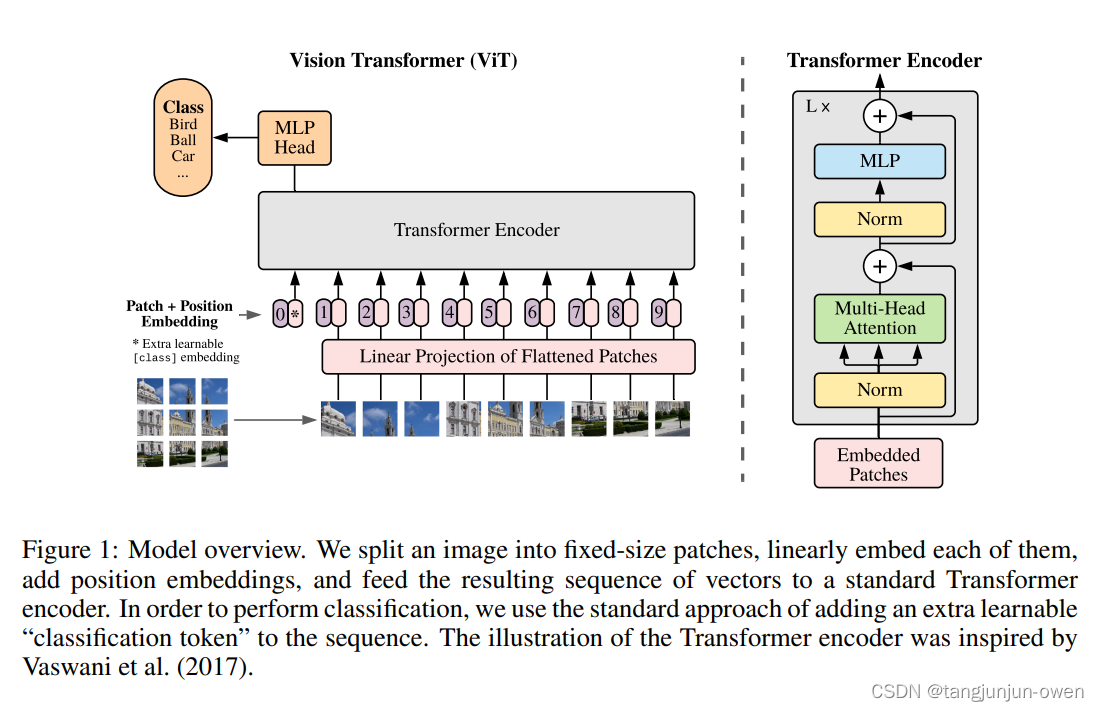

In [31]:
class LayerNorm(nn.LayerNorm):
    """Subclass torch's LayerNorm to handle fp16."""
    """ 混合精度 """
    def forward(self, x: torch.Tensor):
        orig_type = x.dtype
        ret = super().forward(x.type(torch.float32))
        return ret.type(orig_type)

class QuickGELU(nn.Module):
    """1.702 是一个经验常数，调节 Sigmoid 的形状使其更接近于 GELU 的行为。"""
    def forward(self, x: torch.Tensor):
        return x * torch.sigmoid(1.702 * x)


class ResidualAttentionBlock(nn.Module):
    """标准的transformer encoder结构"""
    def __init__(self, d_model: int, n_head: int, attn_mask: torch.Tensor = None):
        super().__init__()

        self.attn = nn.MultiheadAttention(d_model, n_head)
        self.ln_1 = LayerNorm(d_model)
        self.mlp = nn.Sequential(OrderedDict([
            ("c_fc", nn.Linear(d_model, d_model * 4)),
            ("gelu", QuickGELU()),
            ("c_proj", nn.Linear(d_model * 4, d_model))
        ]))
        self.ln_2 = LayerNorm(d_model)
        self.attn_mask = attn_mask

    def attention(self, x: torch.Tensor):
        self.attn_mask = self.attn_mask.to(dtype=x.dtype, device=x.device) if self.attn_mask is not None else None
        return self.attn(x, x, x, need_weights=False, attn_mask=self.attn_mask)[0]

    def forward(self, x: torch.Tensor):
        x = x + self.attention(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

transformer encoder


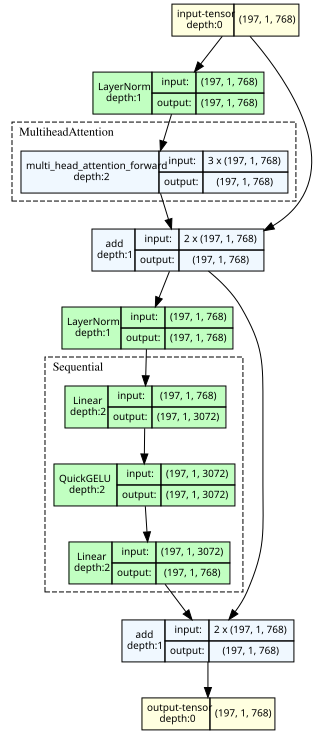

In [32]:
print("transformer encoder")
LND = torch.rand(197,1,768)
encoder = ResidualAttentionBlock(output_dim, n_head=8)
graph = draw_graph(encoder, input_size=LND.shape, expand_nested=True)
graph.visual_graph

In [33]:
class Transformer(nn.Module):
    """ResidualAttentionBlock 的一个循环结构, attn_mask只有问本才需要传递"""
    def __init__(self, width: int, layers: int, heads: int, attn_mask: torch.Tensor = None):
        super().__init__()
        self.width = width
        self.layers = layers
        self.resblocks = nn.Sequential(*[ResidualAttentionBlock(width, heads, attn_mask) for _ in range(layers)])

    def forward(self, x: torch.Tensor):
        return self.resblocks(x)


class VisionTransformer(nn.Module):
    def __init__(self, input_resolution: int, patch_size: int, width: int, layers: int, heads: int, output_dim: int):
        super().__init__()
        self.input_resolution = input_resolution
        self.output_dim = output_dim
        # 利用卷积将图片切分为多个patch
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=width, kernel_size=patch_size, stride=patch_size, bias=False)

        scale = width ** -0.5
        self.class_embedding = nn.Parameter(scale * torch.randn(width))
        # +1 就是cls token
        self.positional_embedding = nn.Parameter(scale * torch.randn((input_resolution // patch_size) ** 2 + 1, width))
        self.ln_pre = LayerNorm(width)

        self.transformer = Transformer(width, layers, heads)

        self.ln_post = LayerNorm(width)
        self.proj = nn.Parameter(scale * torch.randn(width, output_dim))  # 对最后对特征再做一次投影，的到最后的输出维度

    def forward(self, x: torch.Tensor):
        x = self.conv1(x)  # shape = [B,C,H,W] -> [*, emb_dim, patch_size, patch_size]
        x = x.reshape(x.shape[0], x.shape[1], -1)  # shape = [*, emb_dim, patch_size ** 2]
        x = x.permute(0, 2, 1)  # shape = [*, patch_size ** 2, emb_dim]
        x = torch.cat([self.class_embedding.to(x.dtype) + torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device), x], dim=1)  # shape = [*, patch_size ** 2 + 1, emb_dim]
        x = x + self.positional_embedding.to(x.dtype)
        x = self.ln_pre(x)

        x = x.permute(1, 0, 2)  # NLD -> LND
        x = self.transformer(x)
        x = x.permute(1, 0, 2)  # LND -> NLD

        x = self.ln_post(x[:, 0, :])    # 为什么选择0？ 将所有信息汇聚到cls token中

        if self.proj is not None:
            x = x @ self.proj

        return x


vision transformer


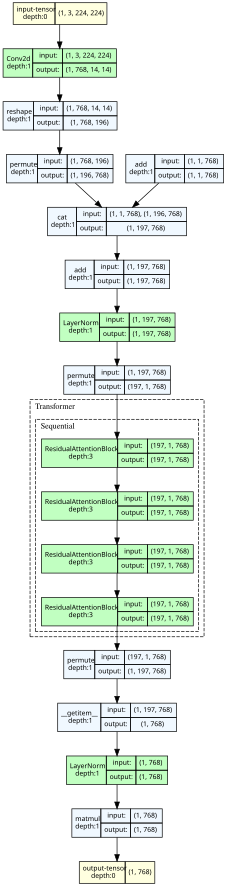

In [34]:
# 示例输入张量的形状为(批次大小, 输入特征维度, 高度, 宽度)
N, C, H, W = 1, 3, 224, 224
x = torch.rand(N, C, H, W)
width = output_dim = 768   # 或者使用其它dim  
heads = 8

vit = VisionTransformer(input_resolution=H, patch_size=16, width=width,layers=4,heads=8,output_dim=output_dim)

print("vision transformer")
graph = draw_graph(vit, input_size=x.shape, expand_nested=True)
graph.visual_graph

## logit_scale参数的作用
### 对比学习中的温度参数
CLIP 的训练目标是通过对比学习方法，让图像和文本在一个共享的嵌入空间中互相对应。对比学习中使用的目标函数是基于软最大值（softmax）的交叉熵损失，而 logits 的缩放是影响模型性能的一个关键因素。该参数对应于对比学习中的温度参数 τ，公式如下：logits=similarity/τ其中，similarity 通常是图像和文本嵌入之间的点积。通过引入一个可学习的 τ，可以动态调整 logits 的范围，从而影响 softmax 的分布，使模型更好地优化目标函数。
### 为什么是 log⁡(1/0.07)
初始值设置为 log⁡(1/0.07) 是因为温度 τ 的默认值为 0.07，这个值在早期的对比学习工作中被发现是一个合适的经验值（例如 SimCLR）。
使用对数形式是为了方便训练：在优化过程中，直接学习 log⁡(1/τ) 的值，而不是 τ 本身。这种设计的好处是确保 τ 始终为正值（通过 τ=exp⁡(−logit_scale)。
### 如何影响训练过程
缩放 logits：调整 logits 的范围，可以改变 softmax 的梯度流分布，避免梯度过大或过小。
动态学习：将温度参数设计为可学习变量，允许模型在训练过程中找到最佳的 τ 值，而不是固定在某个经验值上。

In [ ]:
class CLIP(nn.Module):
    def __init__(self,
                 embed_dim: int,
                 # vision
                 image_resolution: int,
                 vision_layers: Union[Tuple[int, int, int, int], int],
                 vision_width: int,
                 vision_patch_size: int,
                 # text
                 context_length: int,
                 vocab_size: int,
                 transformer_width: int,
                 transformer_heads: int,
                 transformer_layers: int
                 ):
        super().__init__()

        self.context_length = context_length

        if isinstance(vision_layers, (tuple, list)):
            vision_heads = vision_width * 32 // 64
            self.visual = ModifiedResNet(
                layers=vision_layers,
                output_dim=embed_dim,
                heads=vision_heads,
                input_resolution=image_resolution,
                width=vision_width
            )
        else:
            vision_heads = vision_width // 64
            self.visual = VisionTransformer(
                input_resolution=image_resolution,
                patch_size=vision_patch_size,
                width=vision_width,
                layers=vision_layers,
                heads=vision_heads,
                output_dim=embed_dim
            )

        self.transformer = Transformer(
            width=transformer_width,
            layers=transformer_layers,
            heads=transformer_heads,
            attn_mask=self.build_attention_mask()
        )

        self.vocab_size = vocab_size
        self.token_embedding = nn.Embedding(vocab_size, transformer_width)
        self.positional_embedding = nn.Parameter(torch.empty(self.context_length, transformer_width))
        self.ln_final = LayerNorm(transformer_width)

        self.text_projection = nn.Parameter(torch.empty(transformer_width, embed_dim))
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

        self.initialize_parameters()

    def initialize_parameters(self):
        nn.init.normal_(self.token_embedding.weight, std=0.02)
        nn.init.normal_(self.positional_embedding, std=0.01)

        if isinstance(self.visual, ModifiedResNet):
            if self.visual.attnpool is not None:
                std = self.visual.attnpool.c_proj.in_features ** -0.5
                nn.init.normal_(self.visual.attnpool.q_proj.weight, std=std)
                nn.init.normal_(self.visual.attnpool.k_proj.weight, std=std)
                nn.init.normal_(self.visual.attnpool.v_proj.weight, std=std)
                nn.init.normal_(self.visual.attnpool.c_proj.weight, std=std)

            for resnet_block in [self.visual.layer1, self.visual.layer2, self.visual.layer3, self.visual.layer4]:
                for name, param in resnet_block.named_parameters():
                    if name.endswith("bn3.weight"):
                        nn.init.zeros_(param)

        proj_std = (self.transformer.width ** -0.5) * ((2 * self.transformer.layers) ** -0.5)
        attn_std = self.transformer.width ** -0.5
        fc_std = (2 * self.transformer.width) ** -0.5
        for block in self.transformer.resblocks:
            nn.init.normal_(block.attn.in_proj_weight, std=attn_std)
            nn.init.normal_(block.attn.out_proj.weight, std=proj_std)
            nn.init.normal_(block.mlp.c_fc.weight, std=fc_std)
            nn.init.normal_(block.mlp.c_proj.weight, std=proj_std)

        if self.text_projection is not None:
            nn.init.normal_(self.text_projection, std=self.transformer.width ** -0.5)

    def build_attention_mask(self):
        # lazily create causal attention mask, with full attention between the vision tokens
        # pytorch uses additive attention mask; fill with -inf
        mask = torch.empty(self.context_length, self.context_length)
        mask.fill_(float("-inf"))
        mask.triu_(1)  # zero out the lower diagonal
        return mask

    @property
    def dtype(self):
        return self.visual.conv1.weight.dtype

    def encode_image(self, image):
        return self.visual(image.type(self.dtype))

    def encode_text(self, text):
        x = self.token_embedding(text).type(self.dtype)  # [batch_size, n_ctx, d_model]

        x = x + self.positional_embedding.type(self.dtype)
        x = x.permute(1, 0, 2)  # NLD -> LND
        x = self.transformer(x)
        x = x.permute(1, 0, 2)  # LND -> NLD
        x = self.ln_final(x).type(self.dtype)

        # x.shape = [batch_size, n_ctx, transformer.width]
        # take features from the eot embedding (eot_token is the highest number in each sequence)
        x = x[torch.arange(x.shape[0]), text.argmax(dim=-1)] @ self.text_projection

        return x

    def forward(self, image, text):
        image_features = self.encode_image(image)
        text_features = self.encode_text(text)

        # normalized features
        image_features = image_features / image_features.norm(dim=1, keepdim=True)
        text_features = text_features / text_features.norm(dim=1, keepdim=True)

        # cosine similarity as logits
        logit_scale = self.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()

        # shape = [global_batch_size, global_batch_size]
        return logits_per_image, logits_per_text